In [0]:
%pip install tensorflow scikit-learn seaborn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Imports
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

print("All imports successful!")

All imports successful!


In [0]:
# Configs
# Set use_dummy_data = false once 6 csv files uploaded 
USE_DUMMY_DATA = True   # <-- flip to False when real CSVs are ready

LABELS = ["GOOD", "SLOPPY", "BAD"]
EXERCISES = ["CURL", "LATERAL_RAISE"]

# Model input shape: 50 timesteps × 6 channels (ax,ay,az,gx,gy,gz)
WINDOW_SIZE = 50
N_CHANNELS = 6
N_CLASSES = 3
REPS_PER_CLASS = 50   # 50 reps × 3 classes × 2 exercises = 300 total

DATA_DIR = "/dbfs/FileStore/wonkalift"

print(f"Mode: {'DUMMY DATA' if USE_DUMMY_DATA else 'REAL DATA'}")
print(f"Input shape: ({WINDOW_SIZE}, {N_CHANNELS}) → {N_CLASSES} classes")

Mode: DUMMY DATA
Input shape: (50, 6) → 3 classes


In [0]:
def load_real_data():
    '''
    Load 6 csv files from DB filestore
    each file: 50 reps x 301 cols (label + 300 floats)
    Column format: LABEL_EXERCISE, ax0, ay0, az0, gx0, gy0, gz0, ax1, ...
    '''
    all_X = []
    all_Y = []

    for e in EXERCISES:
        for label_index, label in enumerate(LABELS):
            filename = f"{label}_{e}.csv"
            filepath = os.path.join(DATA_DIR, filename)

            df = pd.read_csv(filepath, header=None)
            print(f"Loaded {filepath}: {df.shape}")

            # first col label string - drop
            # next 300 cols = 50 tsteps x 6 channels
            values = df.iloc[:, 1:].values.astype(np.float32)
            X = values.reshape(-1, WINDOW_SIZE, N_CHANNELS)
            all_X.append(X)
            all_Y.extend([label_index] * len(X))
    X = np.concatenate(all_X, axis=0)
    y = np.array(all_Y, dtype=np.int32)
    print(f"\nTotal dataset: X={X.shape}, y={y.shape}")
    return X, y

In [0]:
def generate_dummy_data():
    '''
    For the sake of testing, will use real data.
    '''
    np.random.seed(42)
    all_X = []
    all_y = []

    for exercise_idx, exercise in enumerate(EXERCISES):
        for label_idx, label in enumerate(LABELS):
            reps = []
            for _ in range(REPS_PER_CLASS):
                t = np.linspace(0, 1, WINDOW_SIZE)

                if label == "GOOD":
                    # Clean sinusoidal motion, full amplitude
                    ay = 8.0 * np.sin(2 * np.pi * t) + np.random.normal(0, 0.3, WINDOW_SIZE)
                    gx = 1.5 * np.sin(2 * np.pi * t + 0.5) + np.random.normal(0, 0.1, WINDOW_SIZE)
                elif label == "SLOPPY":
                    # Half amplitude — partial range of motion
                    ay = 4.0 * np.sin(2 * np.pi * t) + np.random.normal(0, 0.3, WINDOW_SIZE)
                    gx = 0.8 * np.sin(2 * np.pi * t + 0.5) + np.random.normal(0, 0.1, WINDOW_SIZE)
                else:  # BAD
                    # High gyro spike — body swing
                    ay = 5.0 * np.sin(2 * np.pi * t) + np.random.normal(0, 0.5, WINDOW_SIZE)
                    gx = 4.0 * np.sin(2 * np.pi * t + 0.3) + np.random.normal(0, 0.5, WINDOW_SIZE)

                # Fill remaining channels with low noise
                ax = np.random.normal(0.5 * exercise_idx, 0.2, WINDOW_SIZE)
                az = np.random.normal(-5.0, 0.3, WINDOW_SIZE)
                gy = np.random.normal(0, 0.2, WINDOW_SIZE)
                gz = np.random.normal(0, 0.2, WINDOW_SIZE)

                window = np.stack([ax, ay, az, gx, gy, gz], axis=1)  # (50, 6)
                reps.append(window)

            all_X.append(np.array(reps))
            all_y.extend([label_idx] * REPS_PER_CLASS)

    X = np.concatenate(all_X, axis=0).astype(np.float32)
    y = np.array(all_y, dtype=np.int32)
    print(f"Dummy dataset: X={X.shape}, y={y.shape}")
    print("Label distribution:", {LABELS[i]: int(np.sum(y == i)) for i in range(N_CLASSES)})
    return X, y


if USE_DUMMY_DATA:
    X, y = generate_dummy_data()
else:
    X, y = load_real_data()

Dummy dataset: X=(300, 50, 6), y=(300,)
Label distribution: {'GOOD': 100, 'SLOPPY': 100, 'BAD': 100}


In [0]:
# Preprocess: normalize + one-hot encode
'''
One-hot encoding converts these nominal (unordered) categories into binary columns ( 0 or 1) to ensure the model interprets them independently, without assigning false numerical rankings.

Normalize: subtract mean and divide by std deviation to ensure the model doesn't overemphasize any particular feature. Prevents it from ignoring its gyro channels.
'''

X_mean = X.mean(axis=(0, 1), keepdims=True)
X_std  = X.std(axis=(0, 1), keepdims=True) + 1e-8  # epsilon prevents division by zero

X_norm = (X - X_mean) / X_std

# One-hot encode labels: [0,1,2] → [[1,0,0],[0,1,0],[0,0,1]]
y_onehot = keras.utils.to_categorical(y, num_classes=N_CLASSES)

print(f"X_norm shape: {X_norm.shape} | range: [{X_norm.min():.2f}, {X_norm.max():.2f}]")
print(f"y_onehot shape: {y_onehot.shape}")
print(f"X_mean: {X_mean.squeeze()}")
print(f"X_std: {X_std.squeeze()}")

# Save normalization stats — needed at inference time on the phone
np.save("/tmp/X_mean.npy", X_mean)
np.save("/tmp/X_std.npy",  X_std)
print("\nNormalization stats saved to /tmp/")


X_norm shape: (300, 50, 6) | range: [-4.44, 4.47]
y_onehot shape: (300, 3)
X_mean: [ 2.5088897e-01  5.6550448e-04 -4.9993439e+00  1.6486192e-02
 -1.4874942e-04 -6.9894170e-04]
X_std: [0.32173654 4.1617293  0.29792523 1.7858667  0.20060652 0.20094524]

Normalization stats saved to /tmp/


In [0]:
# Train/Test split (80/20, stratified)
'''
Stratify:  proportional number of samples from every unique group in your dataset, it ensures your training and testing sets are miniature versions of the original
- Best for classification ML stuff.
'''

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y # ensures each class is proportionally represented in both splits
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train label distribution: {y_train.sum(axis=0).astype(int)}")
print(f"Test  label distribution: {y_test.sum(axis=0).astype(int)}")

Train: (240, 50, 6) | Test: (60, 50, 6)
Train label distribution: [80 80 80]
Test  label distribution: [20 20 20]


In [0]:
# 1D CNN Model
# A CNN applies a sliding filter (kernel) across a sequence looking for local patterns. For images that sequence is 2D (pixels). For our data it's 1D (time).
'''
Concretely, our filters will learn things like:
- "Sharp gyro spike in any 5-sample window → probably BAD (body swing)"
- "Accelerometer peak only reaches half amplitude → probably SLOPPY (partial ROM)"
- "Smooth full-amplitude sine shape → probably GOOD"
'''
def build_model(input_shape=(WINDOW_SIZE, N_CHANNELS), n_classes=N_CLASSES):
    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv1D(32, kernel_size=5, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Block 2
    x = layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Block 3
    x = layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    # Collapse time dimension
    x = layers.GlobalAveragePooling1D()(x)

    # Classifier head
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    return model

model = build_model()
model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 50, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 50, 32)         │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 50, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 25, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 25, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 25, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 12, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,547 (95.89 KB)

 Trainable params: 24,227 (94.64 KB)

 Non-trainable params: 320 (1.25 KB)

Epoch 1/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6042 - loss: 0.9088 - val_accuracy: 0.6667 - val_loss: 1.0386
Epoch 2/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9792 - loss: 0.3898 - val_accuracy: 0.6667 - val_loss: 0.9127
Epoch 3/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9917 - loss: 0.1292 - val_accuracy: 0.6667 - val_loss: 0.7746
Epoch 4/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9958 - loss: 0.0502 - val_accuracy: 0.6667 - val_loss: 0.6031
Epoch 5/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9958 - loss: 0.0303 - val_accuracy: 0.8000 - val_loss: 0.4430
Epoch 6/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0185 - val_accuracy: 0.9167 - val_loss: 0.3100
Epoch 7/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0097 - val_accuracy: 0.9833 - val_loss: 0.2000
Epoch 8/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0074 - val_accuracy: 1.0000 - val_l

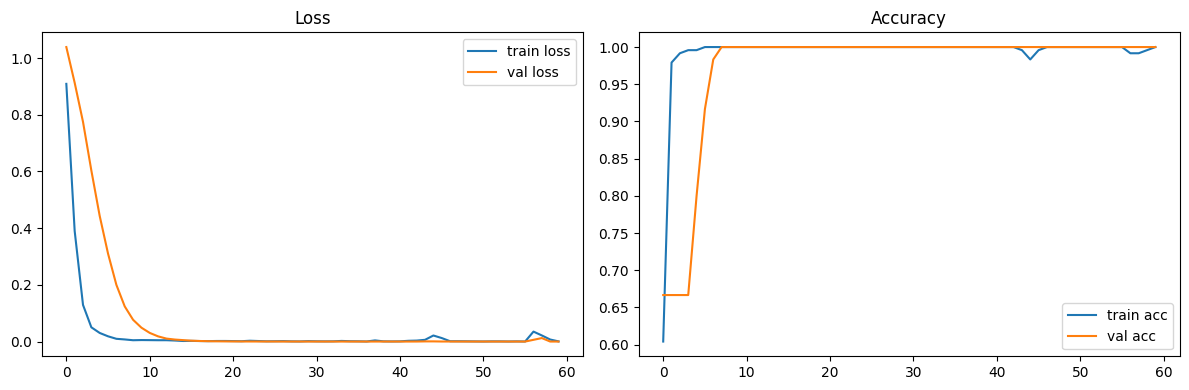

In [0]:
# Train
EPOCHS = 60
BATCH_SIZE = 16

# Early stopping: stops training if val_loss hasn't improved for 10 epochs
# Restores the best weights automatically
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history["loss"], label="train loss")
ax1.plot(history.history["val_loss"], label="val loss")
ax1.set_title("Loss"); ax1.legend()

ax2.plot(history.history["accuracy"], label="train acc")
ax2.plot(history.history["val_accuracy"], label="val acc")
ax2.set_title("Accuracy"); ax2.legend()

plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step

Classification Report:
              precision    recall  f1-score   support

        GOOD       1.00      1.00      1.00        20
      SLOPPY       1.00      1.00      1.00        20
         BAD       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



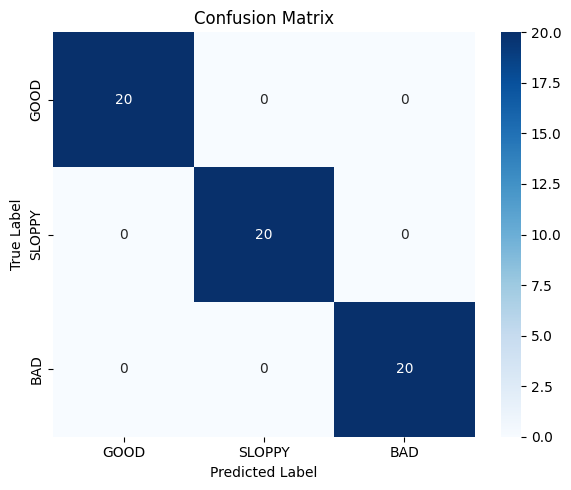

In [0]:
# Evaluate + confusion matrix
'''
confusion matrix is a, table layout that summarizes the performance of a machine learning classification model by comparing actual target values against predicted values.
'''
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=LABELS))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [0]:
# Export to TFLite
# TFLite is a compressed, inference-only format designed for mobile/embedded.
# The converter takes your trained Keras model and produces a .tflite flatbuffer
# that can be bundled into the React Native app and run on-device with no internet.

# NOTE: applying Float_16 quantization - half model size with minimal accuracy loss. 

# NOTE: Serverless compute does not mount DBFS (/dbfs/FileStore is unavailable).
# Files are saved to /tmp and exported as base64 strings for local download.

import base64
import os

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

# Save all outputs to /tmp
os.makedirs("/tmp/wonkalift", exist_ok=True)

tflite_path = "/tmp/wonkalift/wonkalift_classifier.tflite"
mean_path   = "/tmp/wonkalift/X_mean.npy"
std_path    = "/tmp/wonkalift/X_std.npy"

with open(tflite_path, "wb") as f:
    f.write(tflite_model)

np.save(mean_path, X_mean)
np.save(std_path,  X_std)

print(f"TFLite model: {len(tflite_model)/1024:.1f} KB")
print("All files saved to /tmp/wonkalift/")
print("Run the next cell to get base64 download strings.")

INFO:tensorflow:Assets written to: /tmp/tmpnw_eovg0/assets


INFO:tensorflow:Assets written to: /tmp/tmpnw_eovg0/assets


Saved artifact at '/tmp/tmpnw_eovg0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 6), dtype=tf.float32, name='keras_tensor_13')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  281353708241744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  281353599720848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  281353599723344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  281353599719504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  281353599719696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  281353599722768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  281353599720080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  281353599713744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  281353599721424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  281353599716624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  281353599720656: 

W0000 00:00:1771716637.906303    3549 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1771716637.906331    3549 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-02-21 23:30:37.906530: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpnw_eovg0
2026-02-21 23:30:37.907620: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-02-21 23:30:37.907634: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpnw_eovg0
2026-02-21 23:30:37.918178: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-02-21 23:30:37.975139: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpnw_eovg0
2026-02-21 23:30:37.992781: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 86253 microseconds.


In [0]:
import base64
files = {
    "wonkalift_classifier.tflite": "/tmp/wonkalift/wonkalift_classifier.tflite",
    "X_mean.npy": "/tmp/wonkalift/X_mean.npy",
    "X_std.npy": "/tmp/wonkalift/X_std.npy",
}
for name, path in files.items():
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    print("\n=== " + name + " ===")
    print("BASE64_START")
    print(b64)
    print("BASE64_END")


=== wonkalift_classifier.tflite ===
BASE64_START
...
BASE64_END

=== X_mean.npy ===
BASE64_START
k05VTVBZAQB2AHsnZGVzY3InOiAnPGY0JywgJ2ZvcnRyYW5fb3JkZXInOiBGYWxzZSwgJ3NoYXBlJzogKDEsIDEsIDYpLCB9ICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgIAqFdIA+XT4UOqD6n8ANDoc8nvkbuS85N7o=
BASE64_END

=== X_std.npy ===
BASE64_START
k05VTVBZAQB2AHsnZGVzY3InOiAnPGY0JywgJ2ZvcnRyYW5fb3JkZXInOiBGYWxzZSwgJ3NoYXBlJzogKDEsIDEsIDYpLCB9ICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgIAqnuqQ+4yyFQKiJmD5Il+Q/zGtNPpfETT4=
BASE64_END
